In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
df2024 = pd.read_csv('ho24.csv')
df2025 = pd.read_csv('ho25.csv')

In [3]:
df2024

,week,start_dttm,end_dttm,total,no_upg,tms,fo,consumer,ptms_to_ttl,fo_to_ttl,consumer_to_ttl,validation
0,1,11/24/24,11/30/24,3491835,3422494,33652,8761,26928,1.0,0.3,0.8,True
1,2,12/1/24,12/7/24,2921511,2726531,91356,35356,68268,3.1,1.2,2.3,True
2,3,12/8/24,12/14/24,2267383,2132189,32330,47388,55476,1.4,2.1,2.4,True
3,4,12/15/24,12/21/24,1632382,1133218,94890,41091,363183,5.8,2.5,22.2,True
4,5,12/22/24,12/28/24,635615,612957,1747,4966,15945,0.3,0.8,2.5,True
5,6,12/29/24,1/4/25,561016,502821,7919,36510,13766,1.4,6.5,2.5,True


In [4]:
df2025

,week,start_dttm,end_dttm,total,no_upg,tms,fo,consumer,ptms_to_ttl,fo_to_ttl,consumer_to_ttl,validation
0,1,11/23/25,11/29/25,2714890,2670286,15395,6355,22854,0.6,0.2,0.8,True
1,2,11/30/25,12/6/25,2177700,2127488,14368,5530,30314,0.7,0.3,1.4,True
2,3,12/7/25,12/13/25,1831211,1780129,4874,17002,29206,0.3,0.9,1.6,True
3,4,12/14/25,12/20/25,1416454,1095894,14994,44235,261331,1.1,3.1,18.4,True
4,5,12/21/25,12/27/25,672778,634779,92,2173,35734,0.0,0.3,5.3,True
5,6,12/28/25,1/3/26,509643,509477,109,57,0,0.0,0.0,0.0,True


---

In [16]:
weeks = df2024["week"].astype(str)
x = np.arange(len(weeks))
w = 0.42

def yoy_bar(col, c1, c2, title, ylab, fmt):
    fig, ax = plt.subplots(figsize=(10, 5.5))

    y1 = df2024[col].to_numpy()
    y2 = df2025[col].to_numpy()

    ax.bar(x - w/2, y1, w, label="HO25", color=c1)
    ax.bar(x + w/2, y2, w, label="HO26", color=c2)

    ax.set(title=title, xlabel="WEEK", ylabel=ylab)
    ax.set_xticks(x, weeks)
    ax.legend()

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    # top numbers
    for xi, v in zip(x - w/2, y1):
        ax.text(xi, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
    for xi, v in zip(x + w/2, y2):
        ax.text(xi, v, fmt.format(v), ha="center", va="bottom", fontsize=8)

    # dates inside bars (vertical)
    for xi, v, s in zip(x - w/2, y1, df2024["start_dttm"].astype(str)):
        ax.text(xi, v*0.02, s, ha="center", va="bottom", rotation=90,
                fontsize=9, color="white", fontweight="bold")

    for xi, v, s in zip(x + w/2, y2, df2025["start_dttm"].astype(str)):
        ax.text(xi, v*0.02, s, ha="center", va="bottom", rotation=90,
                fontsize=9, color="white", fontweight="bold")

    plt.tight_layout()
    plt.show()

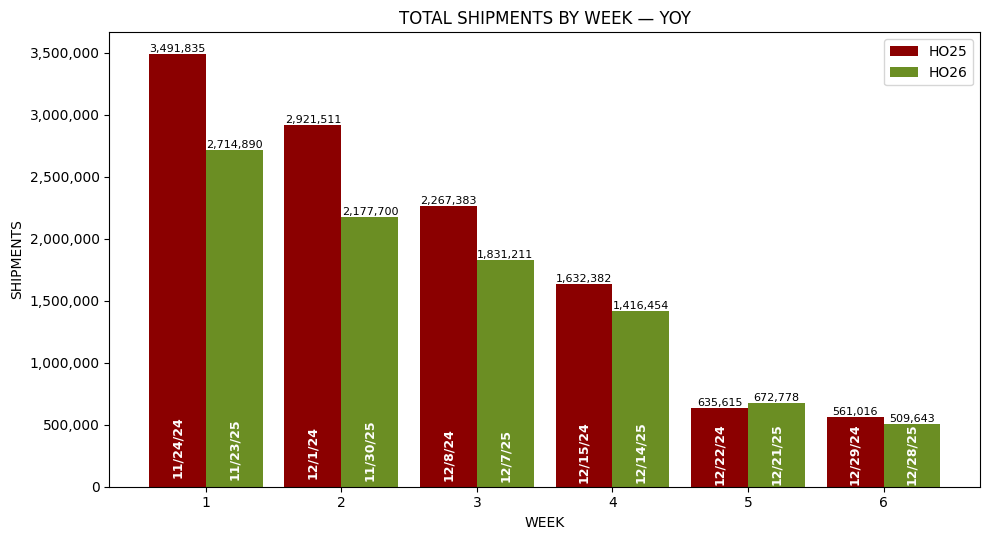

In [17]:
yoy_bar("total", "darkred", "olivedrab", "TOTAL SHIPMENTS BY WEEK — YOY", "SHIPMENTS", "{:,.0f}")

---